# Анализ цен по регионам (подготовка к временным рядам)

Считаем медианную цену за м² по каждому региону помесячно. Фильтруем регионы с достаточным числом сделок.

In [1]:
import os
for _p in ['.', '..', '../..']:
    if os.path.exists(os.path.join(_p, 'data', 'processed')):
        os.chdir(_p)
        break
print('Working dir:', os.getcwd())

Working dir: c:\Users\Vlad\projects\diplom__new


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('Loading merged_clean.csv...')
df = pd.read_csv('data/processed/merged_clean.csv', parse_dates=['date'])
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month
df['period'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
print(f'Загружено: {len(df):,} строк')
print(f'Период: {df["date"].min().date()} - {df["date"].max().date()}')

Loading merged_clean.csv...
Загружено: 16,815,835 строк
Период: 2018-02-19 - 2021-12-31


## 1. Расчёт цены за м²

In [3]:
# Убираем нулевую площадь (деление на 0)
df = df[df['area'] > 0].copy()
df['price_per_sqm'] = df['price'] / df['area']

# Убираем явные выбросы по цене за м²
p1, p99 = df['price_per_sqm'].quantile([0.01, 0.99])
df = df[(df['price_per_sqm'] >= p1) & (df['price_per_sqm'] <= p99)]
print(f'После фильтрации выбросов: {len(df):,} строк')
print(f'Диапазон цены за м²: {p1/1000:.0f}k - {p99/1000:.0f}k руб.')

После фильтрации выбросов: 16,479,517 строк
Диапазон цены за м²: 18k - 427k руб.


## 2. Агрегация по региону и месяцу

In [4]:
monthly = (
    df.groupby(['region', 'year', 'month', 'period'])
    .agg(
        median_price_sqm=('price_per_sqm', 'median'),
        mean_price_sqm=('price_per_sqm', 'mean'),
        count=('price_per_sqm', 'count'),
        median_price=('price', 'median'),
    )
    .reset_index()
    .sort_values(['region', 'period'])
)
print(f'Строк в агрегате: {len(monthly):,}')
print(f'Регионов всего: {monthly["region"].nunique()}')
monthly.head()

Строк в агрегате: 3,116
Регионов всего: 85


,region,year,month,period,median_price_sqm,mean_price_sqm,count,median_price
0,1.0,2018,9,2018-09-01,36486.486486,39193.462109,139,1650000.0
1,1.0,2018,10,2018-10-01,37179.558824,39072.515451,123,1650000.0
2,1.0,2018,11,2018-11-01,38171.617647,40560.480528,203,1700000.0
3,1.0,2018,12,2018-12-01,37619.047619,39013.257950,255,1650000.0
4,1.0,2019,1,2019-01-01,37142.857143,41169.133827,185,1610000.0


## 3. Фильтрация регионов

Оставляем регионы где **≥80% месяцев** имеют **≥100 сделок**.

In [5]:
# Всего месяцев в данных
total_months = monthly['period'].nunique()
print(f'Всего периодов (месяцев): {total_months}')

# Для каждого региона: доля месяцев с >= 100 сделок
region_stats = (
    monthly.groupby('region')
    .agg(
        months_total=('period', 'count'),
        months_100plus=('count', lambda x: (x >= 100).sum()),
        median_monthly_count=('count', 'median'),
        mean_monthly_count=('count', 'mean'),
        total_deals=('count', 'sum'),
        avg_price_sqm=('median_price_sqm', 'mean'),
    )
    .reset_index()
)
region_stats['pct_months_100plus'] = (
    region_stats['months_100plus'] / region_stats['months_total'] * 100
).round(1)

# Фильтр: >= 80% месяцев имеют >= 100 сделок
THRESHOLD_PCT = 80
THRESHOLD_COUNT = 100
filtered = region_stats[region_stats['pct_months_100plus'] >= THRESHOLD_PCT].copy()
filtered = filtered.sort_values('median_monthly_count', ascending=False)

print(f'Регионов прошло фильтр: {len(filtered)} из {len(region_stats)}')
print()
print(filtered[['region', 'median_monthly_count', 'pct_months_100plus', 'total_deals', 'avg_price_sqm']]
      .rename(columns={
          'region': 'Регион',
          'median_monthly_count': 'Медиана сделок/мес',
          'pct_months_100plus': '% мес. >= 100 сделок',
          'total_deals': 'Всего сделок',
          'avg_price_sqm': 'Средн. цена м², руб.',
      })
      .to_string(index=False))

Всего периодов (месяцев): 47
Регионов прошло фильтр: 43 из 85

 Регион  Медиана сделок/мес  % мес. >= 100 сделок  Всего сделок  Средн. цена м², руб.
   54.0             47910.0                  97.6       1656720          61822.125269
   23.0             22258.5                  87.0       1445926          68653.468396
   50.0             16957.0                  85.1       1229069         101652.842896
   77.0             14611.0                  87.0       1375644         197854.478025
   78.0             13504.0                  85.1       1212300         126975.875101
   16.0              8279.0                  88.9        477550          74234.374126
   66.0              7560.0                  88.9        650846          65917.860525
   61.0              6710.0                  88.9        623587          57659.505051
   74.0              5494.5                  95.2        476438          40351.205444
   72.0              5248.0                  97.6        986746          6917

## 4. Сохранение результатов

In [6]:
# Финальный временной ряд — только отфильтрованные регионы
good_regions = filtered['region'].tolist()
ts = monthly[monthly['region'].isin(good_regions)].copy()

ts.to_csv('data/processed/price_by_region_month.csv', index=False)
print(f'Сохранено data/processed/price_by_region_month.csv: {len(ts):,} строк')

# Статистика по регионам
filtered.to_csv('data/processed/regions_stats.csv', index=False)
print(f'Сохранено data/processed/regions_stats.csv: {len(filtered)} регионов')

Сохранено data/processed/price_by_region_month.csv: 1,775 строк
Сохранено data/processed/regions_stats.csv: 43 регионов


## 5. Визуализация: топ-12 регионов по числу сделок

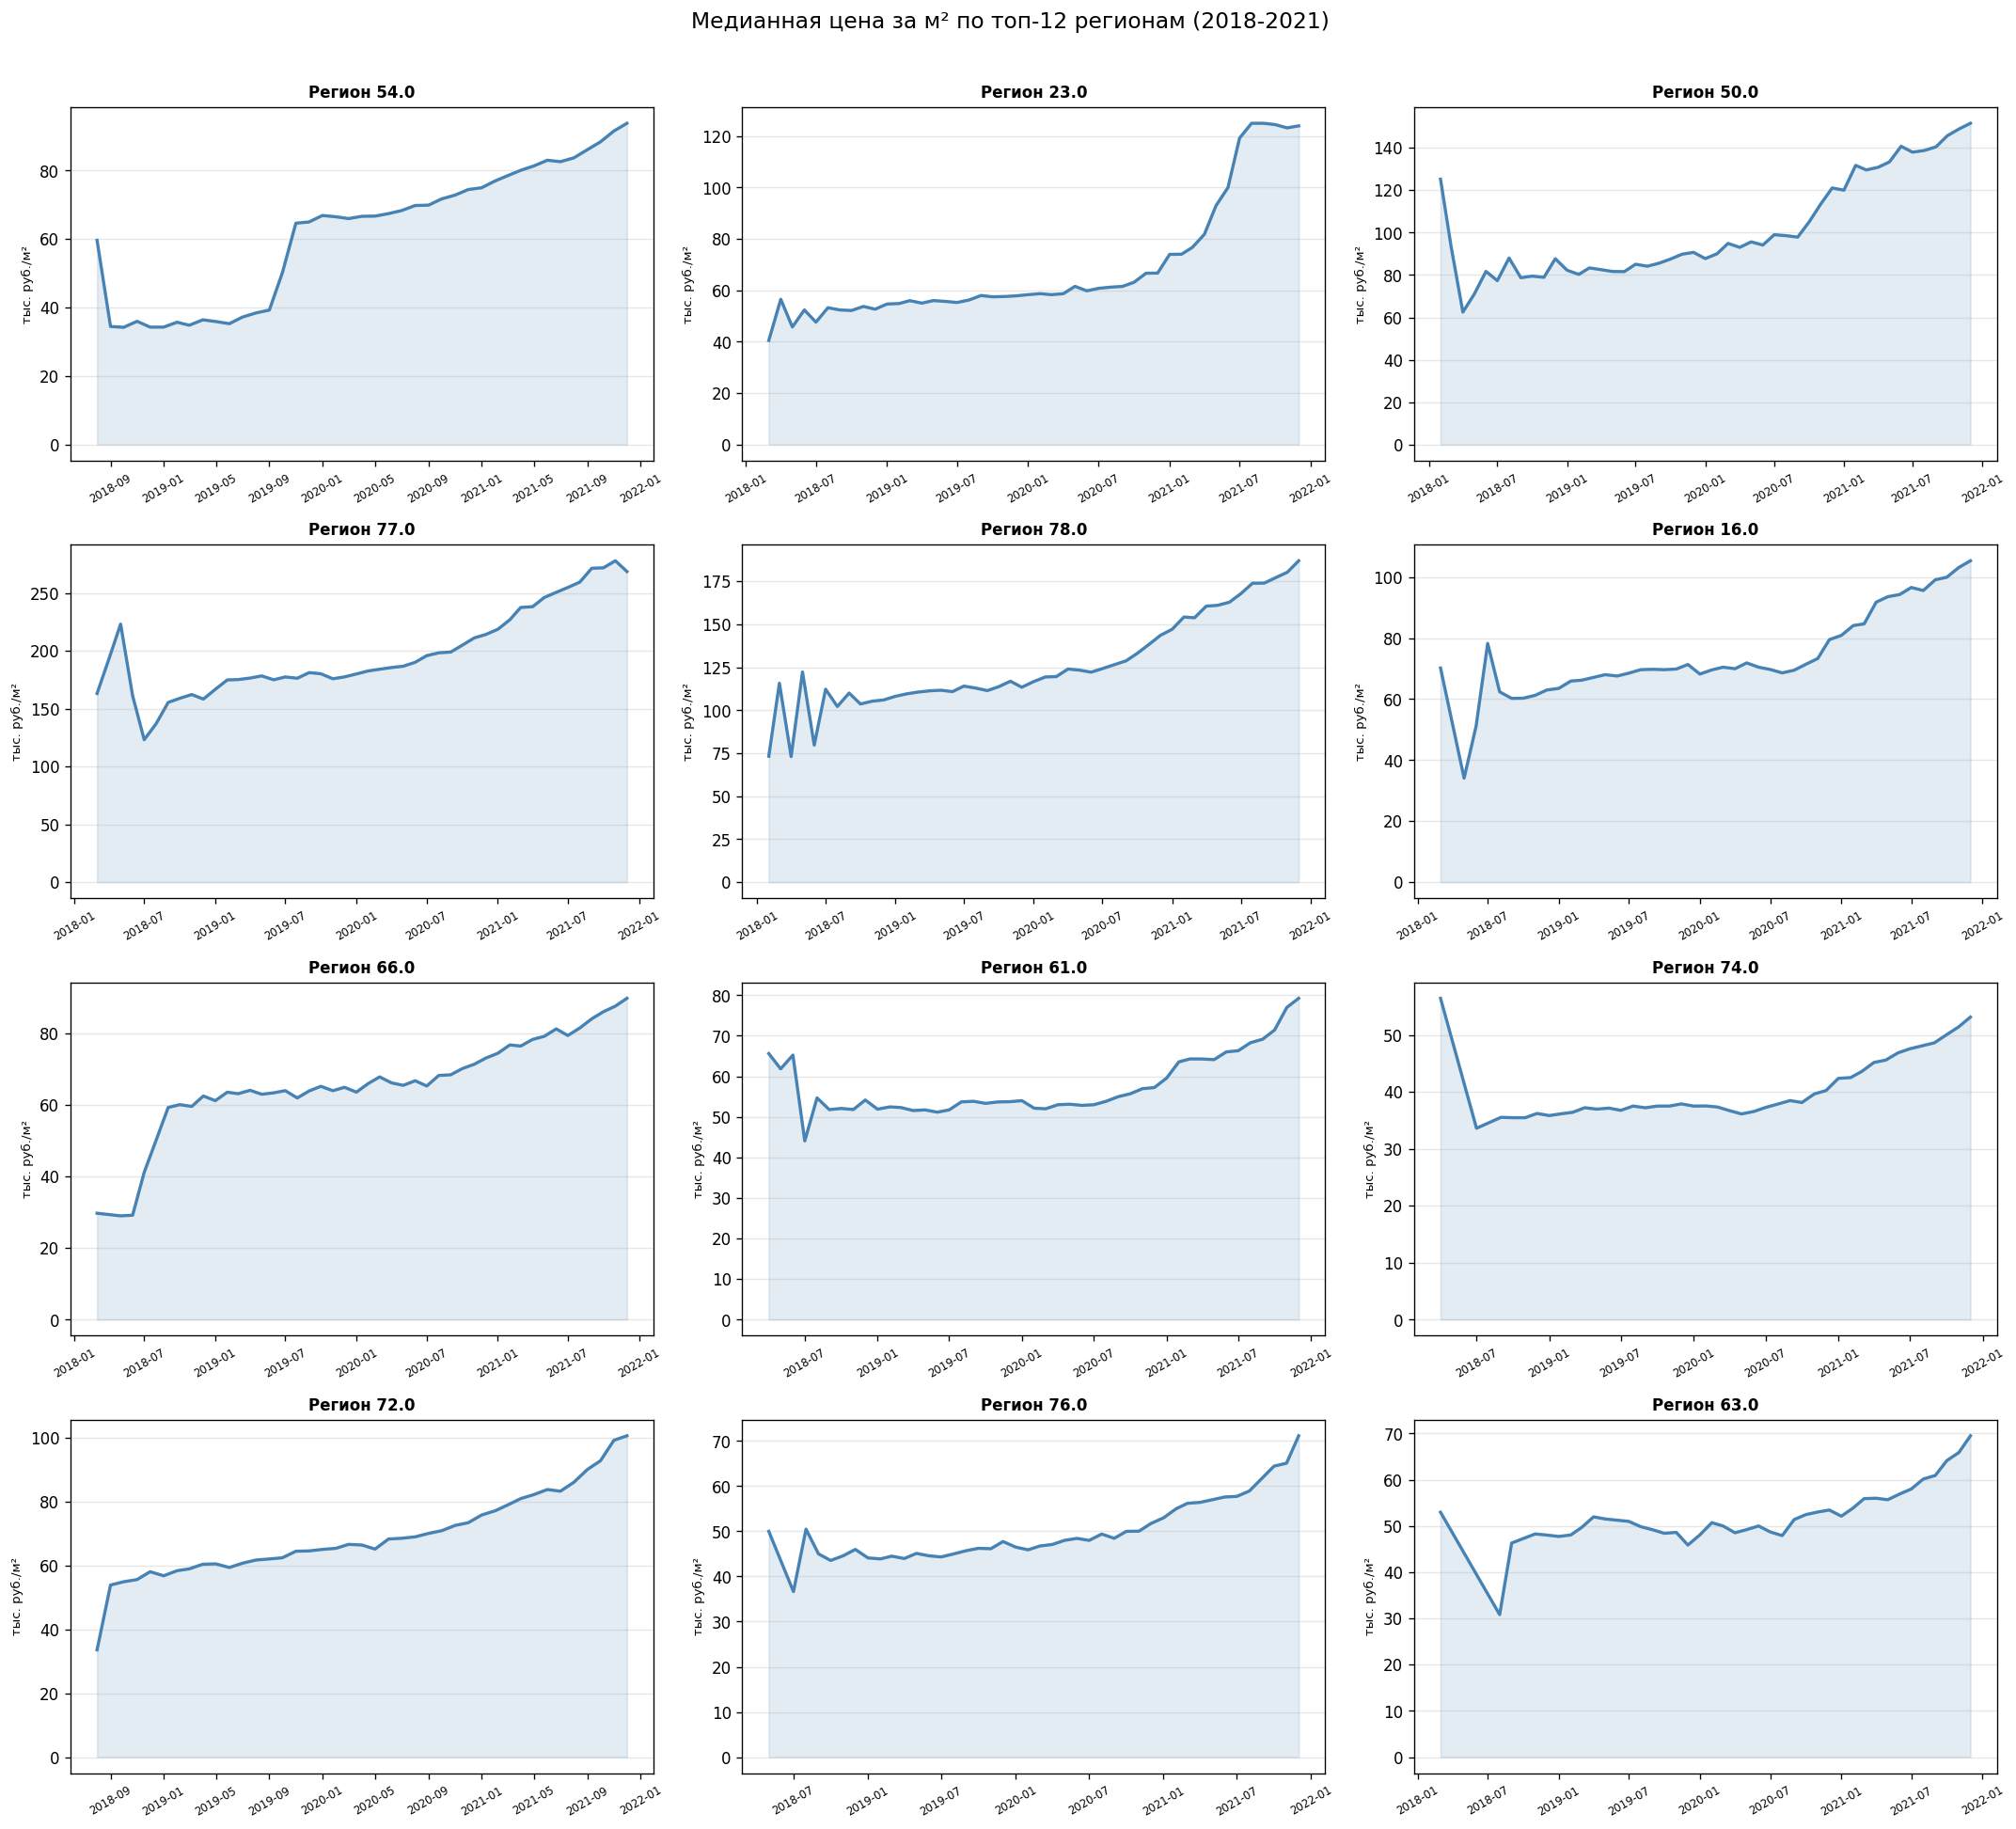

Сохранено: results/figures/price_by_region_top12.png


In [7]:
top12 = filtered.head(12)['region'].tolist()

# Загрузим коды регионов для подписей
try:
    reg_names = pd.read_csv('data/russia_region_codes.csv')
    reg_map = dict(zip(reg_names.iloc[:,0], reg_names.iloc[:,1]))
except Exception:
    reg_map = {}

def reg_label(code):
    return reg_map.get(code, f'Регион {code}')

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
for ax, reg in zip(axes.flat, top12):
    sub = ts[ts['region'] == reg].sort_values('period')
    ax.plot(sub['period'], sub['median_price_sqm'] / 1000, linewidth=2, color='steelblue')
    ax.fill_between(sub['period'], sub['median_price_sqm'] / 1000, alpha=0.15, color='steelblue')
    ax.set_title(reg_label(reg), fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('тыс. руб./м²', fontsize=8)
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f'))
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Медианная цена за м² по топ-12 регионам (2018-2021)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('results/figures/price_by_region_top12.png', bbox_inches='tight')
plt.show()
print('Сохранено: results/figures/price_by_region_top12.png')

## 6. Сравнение регионов на одном графике

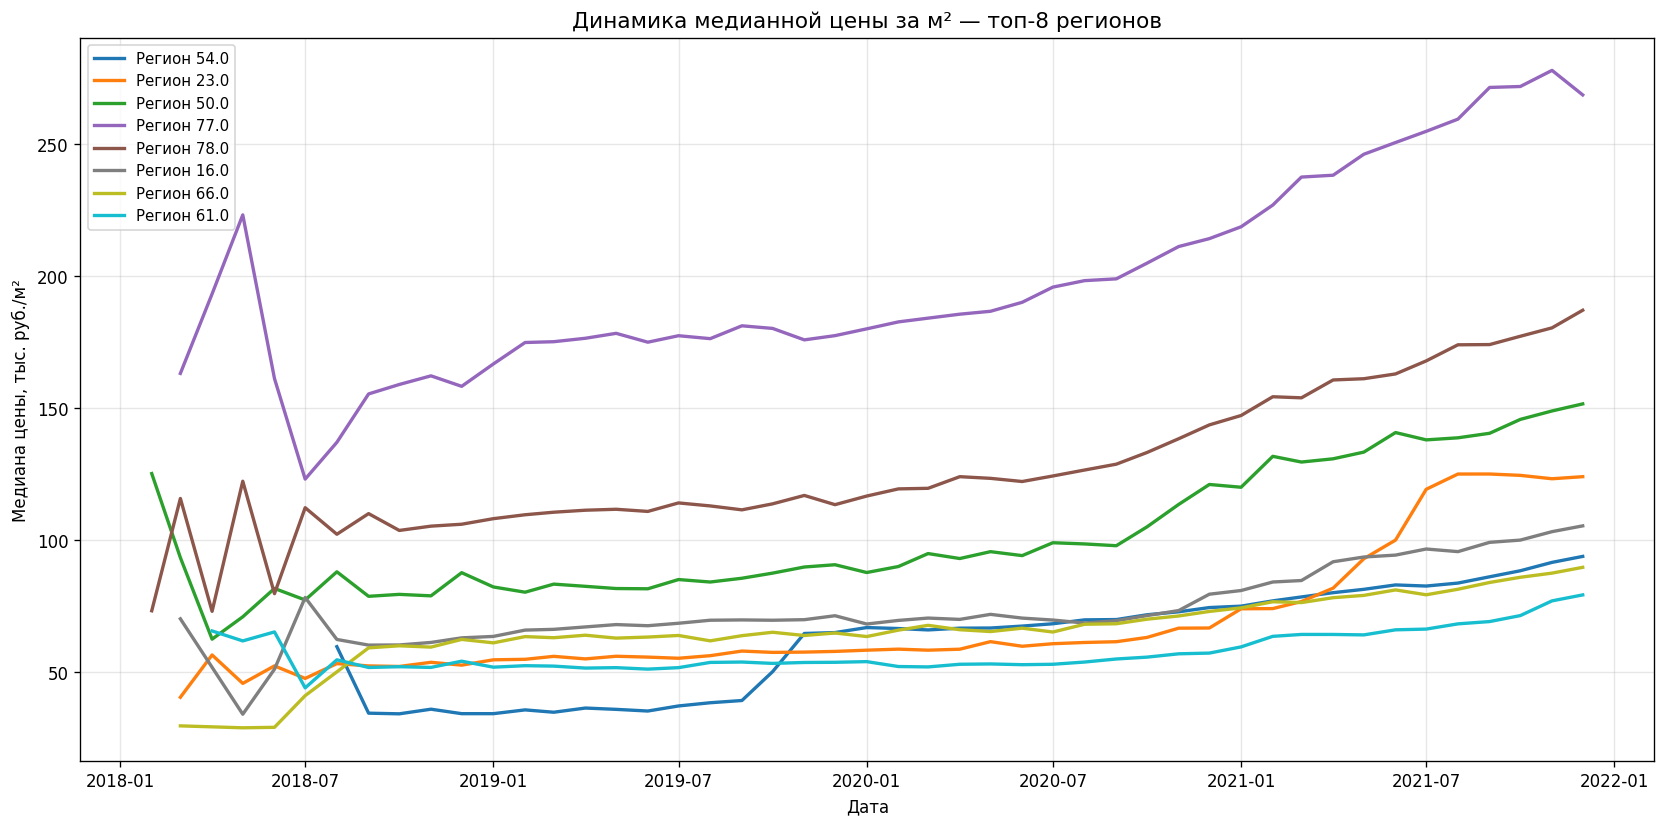

Сохранено: results/figures/price_by_region_comparison.png


In [8]:
top8 = filtered.head(8)['region'].tolist()

fig, ax = plt.subplots(figsize=(14, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(top8)))
for reg, color in zip(top8, colors):
    sub = ts[ts['region'] == reg].sort_values('period')
    ax.plot(sub['period'], sub['median_price_sqm'] / 1000,
            linewidth=2, label=reg_label(reg), color=color)

ax.set_title('Динамика медианной цены за м² — топ-8 регионов', fontsize=13)
ax.set_xlabel('Дата')
ax.set_ylabel('Медиана цены, тыс. руб./м²')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/price_by_region_comparison.png', bbox_inches='tight')
plt.show()
print('Сохранено: results/figures/price_by_region_comparison.png')

## 7. Сезонность

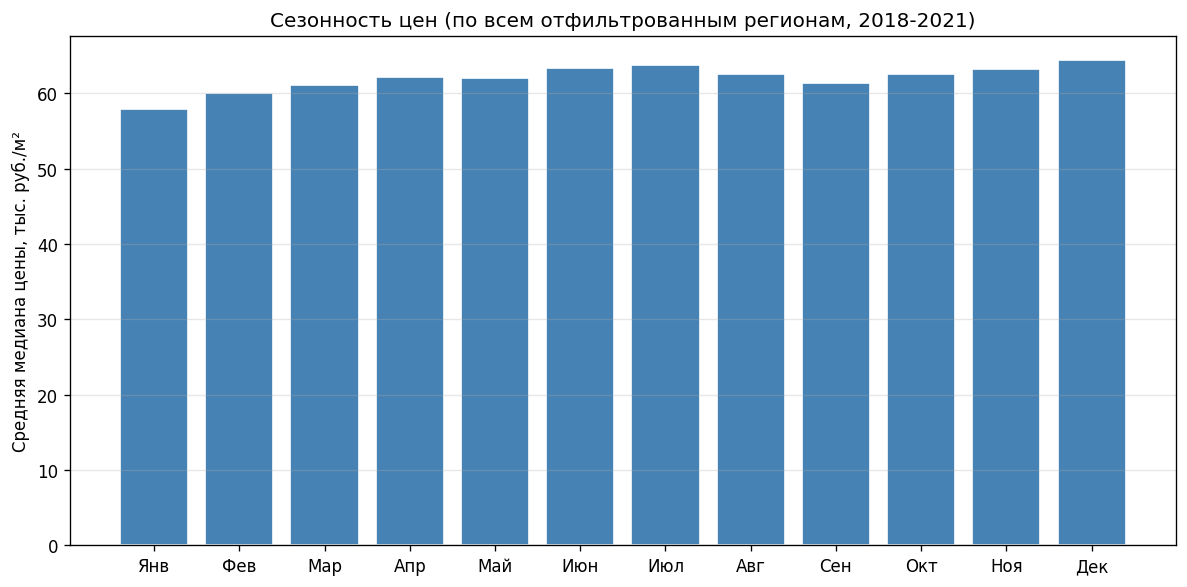

In [9]:
# Средний прирост цены по месяцам (все отфильтрованные регионы)
seasonality = (
    ts.groupby('month')['median_price_sqm']
    .mean()
    .reset_index()
)
month_names = ['Янв','Фев','Мар','Апр','Май','Июн','Июл','Авг','Сен','Окт','Ноя','Дек']

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, 13), seasonality['median_price_sqm'] / 1000, color='steelblue', edgecolor='white')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_ylabel('Средняя медиана цены, тыс. руб./м²')
ax.set_title('Сезонность цен (по всем отфильтрованным регионам, 2018-2021)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/price_seasonality.png', bbox_inches='tight')
plt.show()

## 8. Итог

- Сохранён временной ряд: `data/processed/price_by_region_month.csv`
- Сохранена статистика регионов: `data/processed/regions_stats.csv`
- Регионы с достаточным числом сделок готовы для обучения моделей временных рядов
- Следующий шаг: добавить данные Росстата (2022-2025) и обучить ARIMA/Prophet/LSTM